<a href="https://colab.research.google.com/github/nguyenvuonghongvy/TH_DeepLearning/blob/main/Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN


## 2.1. Nạp thư viện

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

## 2.2. Đọc dữ liệu MNIST

In [3]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:, 1:]
Y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
Y_test = df_test.iloc[:, 0]
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [4]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of Classes:', len(np.unique(Y_train)))
print('Classes:', np.unique(Y_train))
print(Y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of Classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


## 2.3. Trực quan hóa 10 ảnh đầu tiên

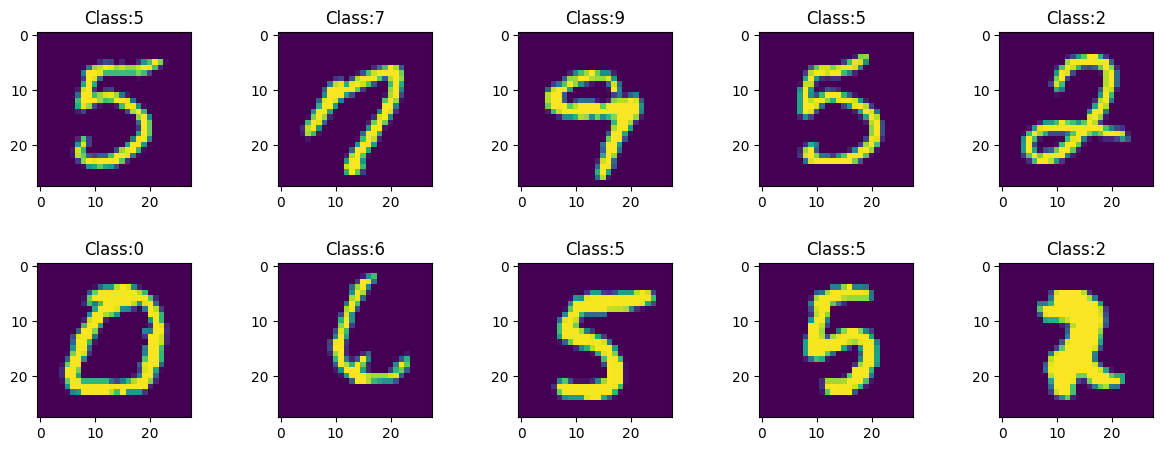

In [7]:
fig, axes = plt.subplots(nrows = 2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(Y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

## 2.4. Chuyển giá trị nhãn thành one-hot encoding

In [15]:
# Re-extract Y_train and Y_test to ensure they are in their original integer label format
# This prevents issues if the cell is run multiple times
Y_train_labels = df_train.iloc[:, 0]
Y_test_labels = df_test.iloc[:, 0]

Y_train = keras.utils.to_categorical(Y_train_labels, num_classes)
Y_test = keras.utils.to_categorical(Y_test_labels, num_classes)

## 2.5. Xây dựng mô hình CNN

In [12]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu')) # Corrected typo here
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        77,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,266 (376.04 KB)

 Trainable params: 96,266 (376.04 KB)

 Non-trainable params: 0 (0.00 B)

## 2.6. Huấn luyện mô hình CNN

In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, Y_train, batch_size=128, epochs =15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.8708 - loss: 0.4747 - val_accuracy: 0.9485 - val_loss: 0.1897
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.9620 - loss: 0.1278 - val_accuracy: 0.9680 - val_loss: 0.1141
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9771 - loss: 0.0779 - val_accuracy: 0.9680 - val_loss: 0.0931
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9824 - loss: 0.0552 - val_accuracy: 0.9690 - val_loss: 0.0932
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.9863 - loss: 0.0449 - val_accuracy: 0.9810 - val_loss: 0.0691
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.9898 - loss: 0.0338 - val_accuracy: 0.9800 - val_loss: 0.0660
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.9918 - loss: 0.0259 - val_accuracy: 0.9770 - val_loss: 0.0788
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 137ms/step - accuracy: 0.9926 - loss: 0.0225

## 2.7. Đánh giá mô hình CNN

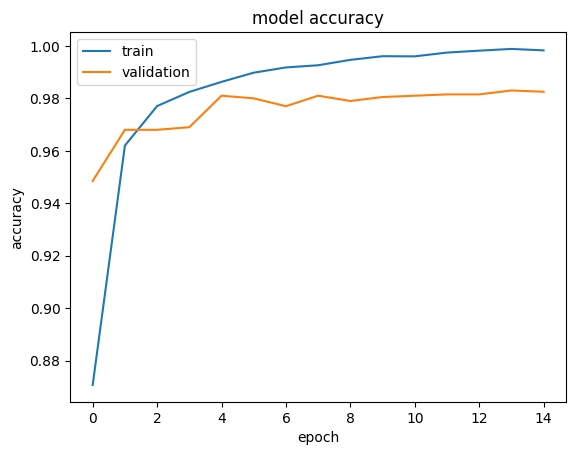

In [17]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

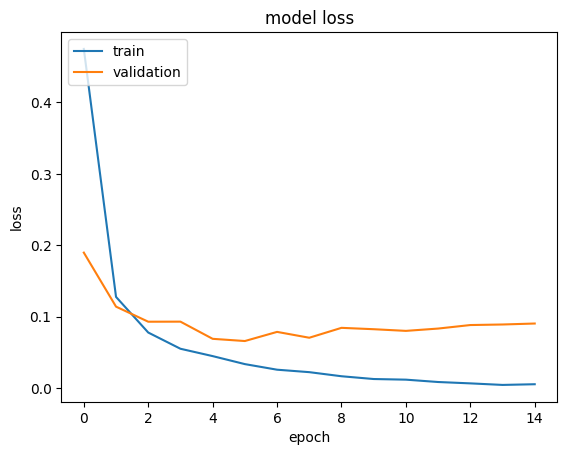

In [18]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## 2.8. Đánh giá mô hình CNN thử nghiệm trên tập test

In [21]:
score = model.evaluate(X_test, Y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9840 - loss: 0.0638
Test loss: 0.0637618824839592
Test accuracy: 0.9839984178543091


## 2.9. Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
[[2.9472035e-08 1.9119960e-05 9.9997783e-01 2.9191561e-13 3.3392659e-21
  6.4728400e-16 3.1576997e-06 2.2683394e-20 6.4117900e-10 2.1509882e-22]]
2 2


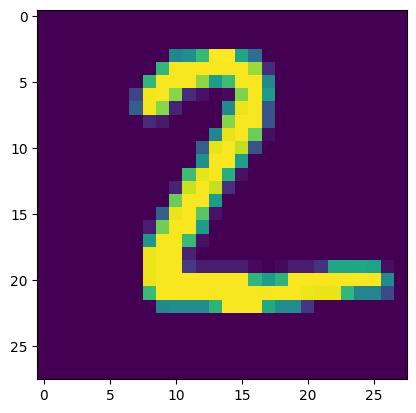

In [22]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(Y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

## 2.10. Lưu tham số mô hình CNN

In [25]:
model.save_weights('cnn.weights.h5')

## 2.11. Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
[[1.20439609e-07 9.99937057e-01 1.17718655e-05 3.01659213e-08
  2.75926268e-05 7.57258150e-08 1.58596563e-07 4.37891822e-06
  1.86729358e-05 6.37607744e-10]]
1 1


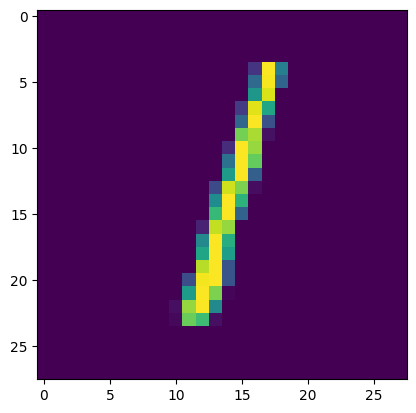

In [27]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(Y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

# BÀI TẬP

In [29]:
#lệnh để giải nén file chứa dataset
!unzip subset_50.zip -d my_dataset

Archive:  subset_50.zip
   creating: my_dataset/Cat/
   creating: my_dataset/Dog/
  inflating: my_dataset/Dog/6588.jpg  
  inflating: my_dataset/Dog/9960.jpg  
  inflating: my_dataset/Dog/623.jpg  
  inflating: my_dataset/Dog/2193.jpg  
  inflating: my_dataset/Dog/10597.jpg  
  inflating: my_dataset/Dog/3919.jpg  
  inflating: my_dataset/Dog/7981.jpg  
  inflating: my_dataset/Dog/5982.jpg  
  inflating: my_dataset/Dog/6234.jpg  
  inflating: my_dataset/Dog/6399.jpg  
  inflating: my_dataset/Dog/1269.jpg  
  inflating: my_dataset/Dog/6197.jpg  
  inflating: my_dataset/Dog/10730.jpg  
  inflating: my_dataset/Dog/7737.jpg  
  inflating: my_dataset/Dog/10054.jpg  
  inflating: my_dataset/Dog/3863.jpg  
  inflating: my_dataset/Dog/11925.jpg  
  inflating: my_dataset/Dog/6241.jpg  
  inflating: my_dataset/Dog/10924.jpg  
  inflating: my_dataset/Dog/7966.jpg  
  inflating: my_dataset/Dog/2081.jpg  
  inflating: my_dataset/Dog/2008.jpg  
  inflating: my_dataset/Dog/3750.jpg  
  inflating: my_d

In [32]:
import os
import cv2
from sklearn.model_selection import train_test_split

X = []
y = []
dataset_path = 'my_dataset'

cat_dir = os.path.join(dataset_path, 'Cat')
for img_name in os.listdir(cat_dir):
    img_path = os.path.join(cat_dir, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (64, 64))
        X.append(img)
        y.append(0)

dog_dir = os.path.join(dataset_path, 'Dog')
for img_name in os.listdir(dog_dir):
    img_path = os.path.join(dog_dir, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (64, 64))
        X.append(img)
        y.append(1)

X = np.array(X)
y = np.array(y)

# Chia tập train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khai báo thông số
num_classes = 2 # Chỉ có 2 lớp (Cat và Dog)
input_shape = (64, 64, 1)

# Chuẩn hóa dữ liệu đưa về [0, 1] như hướng dẫn
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Reshape mảng để đưa vào mô hình [cite: 339, 342]
X_train = X_train.reshape(X_train.shape[0], 64, 64, 1)
X_test = X_test.reshape(X_test.shape[0], 64, 64, 1)

# Chuyển nhãn thành one-hot encoding [cite: 406, 408]
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("Kích thước X_train:", X_train.shape)
print("Kích thước y_train:", y_train.shape)

Kích thước X_train: (40, 64, 64, 1)
Kích thước y_train: (40, 2)


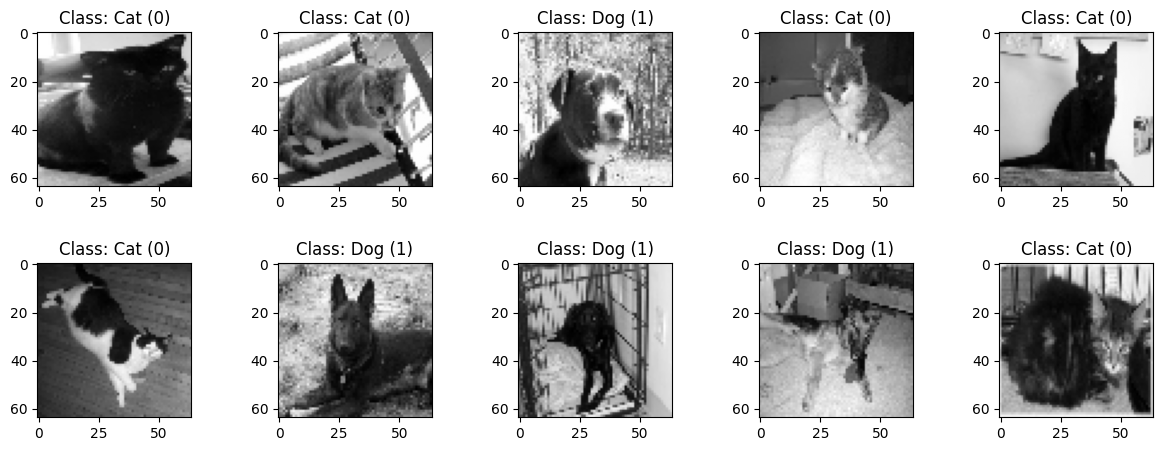

In [35]:
# 2.3. Trực quan hóa 10 ảnh đầu tiên
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(64, 64), cmap='gray')

    label_index = np.argmax(y_train[i])
    class_name = "Cat (0)" if label_index == 0 else "Dog (1)"

    ax[i].title.set_text('Class: ' + class_name)

plt.subplots_adjust(hspace=0.5)
plt.show()

In [33]:
model = Sequential()
model.add(Input(shape=input_shape))

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))


model.add(Flatten())

model.add(Dense(units=num_classes, activation='softmax'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │        25,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,906 (171.51 KB)

 Trainable params: 43,906 (171.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.5278 - loss: 0.7856 - val_accuracy: 0.2500 - val_loss: 0.7852
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7500 - loss: 0.6740 - val_accuracy: 0.7500 - val_loss: 0.6721
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6389 - loss: 0.6709 - val_accuracy: 0.7500 - val_loss: 0.6928
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8611 - loss: 0.6455 - val_accuracy: 0.2500 - val_loss: 0.7400
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6111 - loss: 0.6377 - val_accuracy: 0.2500 - val_loss: 0.8352
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7778 - loss: 0.5814 - val_accuracy: 0.2500 - val_loss: 0.7354
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8889 - loss: 0.5343 - val_accuracy: 0.2500 - val_loss: 0.7872
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9167 - loss: 0.4549 - val_accuracy: 0.5000 - val_loss: 0.6838

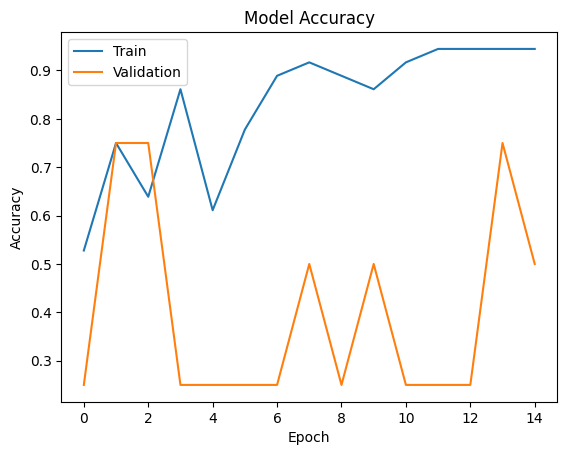

1/1 - 0s - 82ms/step - accuracy: 0.5000 - loss: 1.2965
Test loss: 1.2965179681777954
Test accuracy: 0.5


In [34]:

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


model_fit = model.fit(X_train, y_train, batch_size=8, epochs=15, validation_split=0.1, verbose=1)


plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

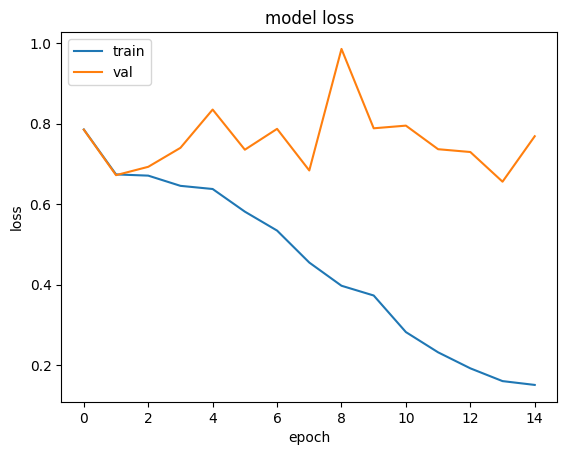

In [36]:
# 2.8. Trực quan hóa biểu đồ Model Loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()